In [1]:
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

# Read and first look

In [2]:
df = pd.read_csv('data.csv', encoding='cp1251')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.info()
df.describe()
#df.shape

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [4]:
df.duplicated().sum()

np.int64(5268)

In [5]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# Data clearing

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.dropna(inplace=True)

In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [9]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [10]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDay'] = df['InvoiceDate'].dt.weekday
df['InvoiceHour'] = df['InvoiceDate'].dt.hour

In [11]:
df = df[df['UnitPrice'] > 0]
df = df[df['UnitPrice'] != 0]

In [12]:
df['TransactionType'] = df.apply(lambda row: 'return' if row['Quantity'] < 0 else 'sale', axis=1)
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,InvoiceDay,InvoiceHour,TransactionType
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,2,8,sale
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2,8,sale
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,2,8,sale
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2,8,sale
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2,8,sale
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,12,4,12,sale
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12,4,12,sale
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,12,4,12,sale
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,12,4,12,sale


In [13]:
df['TotalRevenue'] = df['Quantity'] * df['UnitPrice']

In [14]:
df_returns = df[df['TransactionType'] == 'return'].copy()
df_sales = df[df['TransactionType'] == 'sale'].copy()

In [15]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,InvoiceDay,InvoiceHour,TransactionType,TotalRevenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,12,2,8,sale,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2,8,sale,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,12,2,8,sale,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2,8,sale,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,12,2,8,sale,20.34


# Data analysis

## Time analysis

In [16]:
month_revenue = df.groupby('InvoiceMonth')['TotalRevenue'].sum()
max_month = month_revenue.idxmax()
max_revenue_per_month = month_revenue.max()
print(f'best month: {pd.to_datetime(max_month, format='%m').month_name()}, max revenue: {max_revenue_per_month}')


best month: November, max revenue: 1126815.07


In [17]:
orders_per_weekday = df.groupby('InvoiceDay')['InvoiceNo'].nunique()
max_weekday = orders_per_weekday.idxmax()
max_orders_per_weekday = orders_per_weekday.max()
print(f'best weekday: {pd.to_datetime(max_weekday, format='%u').day_name()}, max orders: {max_orders_per_weekday}')

best weekday: Monday, max orders: 4977


## Product analysis

In [18]:
products_by_qty = df.groupby('StockCode')['Quantity'].sum().reset_index()
products_by_qty.sort_values(by='Quantity',ascending=False).head(10)

,StockCode,Quantity
2812,84077,53119
1092,22197,48689
3235,85099B,44963
3069,84879,35215
3249,85123A,34185
425,21212,33386
1923,23084,27045
1356,22492,25880
1473,22616,25305
914,21977,24129


In [19]:
products_by_total_revenue = df.groupby('StockCode')['TotalRevenue'].sum().reset_index()
products_by_total_revenue.sort_values(by='TotalRevenue', ascending=False).head(10)

,StockCode,TotalRevenue
1292,22423,132567.70
3249,85123A,93923.15
3235,85099B,83056.52
2599,47566,67628.43
3683,POST,66710.24
3069,84879,56331.91
1923,23084,51042.84
1366,22502,46963.10
2755,79321,45915.41
989,22086,41423.78


In [20]:
number_of_unique_products = df['StockCode'].nunique()

In [21]:
avg_price = df_sales.groupby('StockCode')['UnitPrice'].mean().reset_index()
avg_price.sort_values(by='UnitPrice', ascending=False).head(10)

,StockCode,UnitPrice
3661,DOT,744.147500
3662,M,178.406129
1673,22827,158.076923
1674,22828,156.428571
1508,22656,146.750000
1507,22655,143.421053
1669,22823,118.076923
1672,22826,114.024390
774,21769,66.360000
1771,22929,63.915385


## Client Analysis

In [22]:
number_of_customers = df['CustomerID'].nunique()

In [23]:
price_per_order = df_sales.groupby(['CustomerID','InvoiceNo']).agg( TotalRevenue = ('TotalRevenue','sum'))
price_per_order
avg_price_per_order_by_customer = price_per_order.groupby('CustomerID')['TotalRevenue'].mean().reset_index()
avg_price_per_order_by_customer.head(10)

,CustomerID,TotalRevenue
0,12346.0,77183.600000
1,12347.0,615.714286
2,12348.0,449.310000
3,12349.0,1757.550000
4,12350.0,334.400000
5,12352.0,313.255000
6,12353.0,89.000000
7,12354.0,1079.400000
8,12355.0,459.400000
9,12356.0,937.143333


In [24]:
clients_by_order_qty = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
clients_by_order_qty.sort_values(by='InvoiceNo', ascending=False).head(10)

,CustomerID,InvoiceNo
1894,14911.0,248
330,12748.0,223
4041,17841.0,169
1673,14606.0,128
568,13089.0,118
2191,15311.0,118
487,12971.0,89
1614,14527.0,86
802,13408.0,81
2721,16029.0,76


In [25]:
clients_by_purchases = df_sales.groupby('CustomerID')['TotalRevenue'].sum().reset_index()
clients_by_purchases.sort_values(by='TotalRevenue', ascending=False).head(10)

,CustomerID,TotalRevenue
1689,14646.0,280206.02
4201,18102.0,259657.30
3728,17450.0,194390.79
3008,16446.0,168472.50
1879,14911.0,143711.17
55,12415.0,124914.53
1333,14156.0,117210.08
3771,17511.0,91062.38
2702,16029.0,80850.84
0,12346.0,77183.60


## Geographical analysis

In [26]:
total_revenue_by_country = df.groupby('Country')['TotalRevenue'].sum().reset_index()
total_revenue_by_country

,Country,TotalRevenue
0,Australia,137009.770
1,Austria,10154.320
2,Bahrain,548.400
3,Belgium,40910.960
4,Brazil,1143.600
5,Canada,3666.380
6,Channel Islands,20076.390
7,Cyprus,12858.760
8,Czech Republic,707.720
9,Denmark,18768.140


In [27]:
total_customers_by_country = df.groupby('Country')['CustomerID'].nunique()
total_customers_by_country = total_customers_by_country.reset_index(name='Count')
total_customers_by_country
total_customers_by_country.sort_values(by='Count', ascending=False).head(10)

,Country,Count
35,United Kingdom,3949
14,Germany,95
13,France,87
30,Spain,31
3,Belgium,25
32,Switzerland,21
26,Portugal,19
18,Italy,15
12,Finland,12
1,Austria,11


In [28]:
#price_per_order = df.groupby(['Country','InvoiceNo']).agg( TotalOrderRevenue = ('TotalRevenue','sum'))
avg_order_price_by_country = df.groupby(['Country','InvoiceNo']).agg( TotalOrderRevenue = ('TotalRevenue','sum')).groupby('Country')['TotalOrderRevenue'].mean()
avg_order_price_by_country

Country
Australia               1985.648841
Austria                  534.437895
Bahrain                  274.200000
Belgium                  343.789580
Brazil                  1143.600000
Canada                   611.063333
Channel Islands          608.375455
Cyprus                   642.938000
Czech Republic           141.544000
Denmark                  893.720952
EIRE                     783.704639
European Community       258.350000
Finland                  465.140417
France                   429.314520
Germany                  367.345721
Greece                   785.086667
Iceland                  615.714286
Israel                  1164.733333
Italy                    307.100182
Japan                   1262.165000
Lebanon                 1693.880000
Lithuania                415.265000
Malta                    250.547000
Netherlands             2846.615400
Norway                   879.086500
Poland                   300.547500
Portugal                 414.225143
RSA                 

# Advanced analysis

## RFM analysis

In [29]:
recency = df_sales.groupby('CustomerID')['InvoiceDate'].max()
frequency = df_sales.groupby('CustomerID')['InvoiceNo'].nunique()
monetary = df_sales.groupby('CustomerID')['TotalRevenue'].sum()
clients_inf = pd.concat([recency, frequency, monetary], axis = 1)
clients_inf = clients_inf.rename(columns={'InvoiceDate': 'LastInv', 'InvoiceNo': 'TotalInv', 'TotalRevenue': 'TotalPurchase'})
clients_inf

,LastInv,TotalInv,TotalPurchase
CustomerID,,,
12346.0,2011-01-18 10:01:00,1,77183.60
12347.0,2011-12-07 15:52:00,7,4310.00
12348.0,2011-09-25 13:13:00,4,1797.24
12349.0,2011-11-21 09:51:00,1,1757.55
12350.0,2011-02-02 16:01:00,1,334.40
...,...,...,...
18280.0,2011-03-07 09:52:00,1,180.60
18281.0,2011-06-12 10:53:00,1,80.82
18282.0,2011-12-02 11:43:00,2,178.05


In [30]:
current_date = df['InvoiceDate'].max() + pd.Timedelta(hours= 4)
delta_date = df['InvoiceDate'].max() - df['InvoiceDate'].min()
time_interval_1 = pd.Interval(df['InvoiceDate'].min(), df['InvoiceDate'].min() + (delta_date / 3))
time_interval_2 = pd.Interval(df['InvoiceDate'].min() + (delta_date / 3), df['InvoiceDate'].min() + (delta_date / 1.5))
time_interval_3 = pd.Interval(df['InvoiceDate'].min() + (delta_date / 1.5), current_date)
#df['InvoiceDate'].min()
#time_delta_1

In [31]:
clients_inf['R'] = clients_inf.apply(lambda row: 3 if row['LastInv'] in time_interval_3 else (2 if row['LastInv'] in time_interval_2 else 1), axis=1)

In [32]:
clients_inf['F'] = clients_inf.apply(lambda row: 3 if row['TotalInv'] > 6 else (2 if row['TotalInv'] in [4, 5, 6] else 1), axis=1)

In [33]:
clients_inf['M'] = clients_inf.apply(lambda row: 3 if row['TotalPurchase'] >= 3750 else (2 if row['TotalPurchase'] > 1250 and row['TotalPurchase'] < 3750 else 1), axis=1)

In [34]:
clients_inf['RFM'] = clients_inf.apply(lambda row: str(row['R']) + str(row['F']) + str(row['M']), axis=1)

In [35]:
clients_inf

,LastInv,TotalInv,TotalPurchase,R,F,M,RFM
CustomerID,,,,,,,
12346.0,2011-01-18 10:01:00,1,77183.60,1,1,3,113
12347.0,2011-12-07 15:52:00,7,4310.00,3,3,3,333
12348.0,2011-09-25 13:13:00,4,1797.24,3,2,2,322
12349.0,2011-11-21 09:51:00,1,1757.55,3,1,2,312
12350.0,2011-02-02 16:01:00,1,334.40,1,1,1,111
...,...,...,...,...,...,...,...
18280.0,2011-03-07 09:52:00,1,180.60,1,1,1,111
18281.0,2011-06-12 10:53:00,1,80.82,2,1,1,211
18282.0,2011-12-02 11:43:00,2,178.05,3,1,1,311


## Order items analysis

In [36]:
avg_products_qty_per_order = df_sales.groupby('InvoiceNo')['Quantity'].sum().mean()
avg_products_qty_per_order

np.float64(278.00571983595944)

In [37]:
best_products = df_sales.groupby('Description').size().reset_index(name='Count').sort_values(by='Count', ascending=False)
best_products.head(5)

,Description,Count
3698,WHITE HANGING HEART T-LIGHT HOLDER,2016
2767,REGENCY CAKESTAND 3 TIER,1713
1762,JUMBO BAG RED RETROSPOT,1615
216,ASSORTED COLOUR BIRD ORNAMENT,1395
2345,PARTY BUNTING,1389


In [38]:
qwe = df_sales.groupby('InvoiceNo')['Description'].size().reset_index(name='Count')
#qwe = df_sales.groupby('InvoiceNo').merge(df['Description'])
single_order_count = len(qwe[qwe['Count'] == 1])
single_order_count

1395

In [39]:
price_per_order_sales = df_sales.groupby(['InvoiceNo']).agg( TotalOrderRevenue = ('TotalRevenue','sum'))
price_per_order_sales

,TotalOrderRevenue
InvoiceNo,
536365,139.12
536366,22.20
536367,278.73
536368,70.05
536369,17.85
...,...
581583,124.60
581584,140.64
581585,329.05


In [40]:
price_per_order_sales = df_sales.groupby(['InvoiceNo']).agg( TotalOrderRevenue = ('TotalRevenue','sum'))
def classify_order(row):
    revenue = row['TotalOrderRevenue']
    if revenue >= 5000:
        return 'very expensive'
    elif revenue >= 600 and revenue < 5000:
        return 'expensive'
    elif revenue >= 200 and revenue < 600:
        return 'coommon'
    elif revenue >= 0 and revenue < 200:
        return 'cheap'
    else:
        'none'

price_per_order_sales['type'] = price_per_order_sales.apply(classify_order, axis=1)
price_per_order_sales['TotalOrderRevenue'].mean()

np.float64(479.56016047917126)

In [41]:
avg_revenue_per_weekday = df_sales.groupby(['InvoiceNo']).agg(TotalOrderRevenue =('TotalRevenue','sum')).reset_index()
avg_revenue_per_weekday = avg_revenue_per_weekday.merge(df_sales[['InvoiceNo','InvoiceDay']], on='InvoiceNo')
days= {0:'monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Fryday', 5: 'Saturday', 6: 'Sunday'}
week = ['monday', 'Tuesday', 'Wednesday', 'Thursday', 'Fryday', 'Saturday', 'Sunday']
avg_revenue_per_weekday['InvoiceDay'] = avg_revenue_per_weekday['InvoiceDay'].map(days)
avg_revenue_per_weekday['InvoiceDay'] = pd.Categorical(avg_revenue_per_weekday['InvoiceDay'], categories=week, ordered=True)
avg_revenue_per_weekday = avg_revenue_per_weekday.groupby('InvoiceDay')['TotalOrderRevenue'].mean().reset_index()
avg_revenue_per_weekday = avg_revenue_per_weekday.rename(columns={'InvoiceDay': 'WeekDay', 'TotalOrderRevenue': 'AverageRevenue'})
avg_revenue_per_weekday

,WeekDay,AverageRevenue
0,monday,928.706583
1,Tuesday,745.129957
2,Wednesday,772.820057
3,Thursday,792.542257
4,Fryday,682.390265
5,Sunday,524.295671


# Visualization

## RFM

<Axes: xlabel='InvoiceMonth', ylabel='TotalRevenue'>

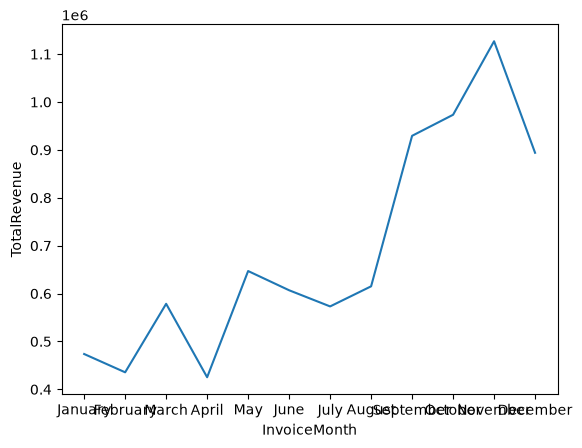

In [42]:
# month revenue
month_revenue = month_revenue.reset_index()
month_revenue['InvoiceMonth'] = pd.to_datetime(month_revenue['InvoiceMonth'], format='%m').dt.month_name()
sns.lineplot(month_revenue, x='InvoiceMonth', y='TotalRevenue')

## Top 10 products

<Axes: xlabel='Total Quantity', ylabel='Product Name'>

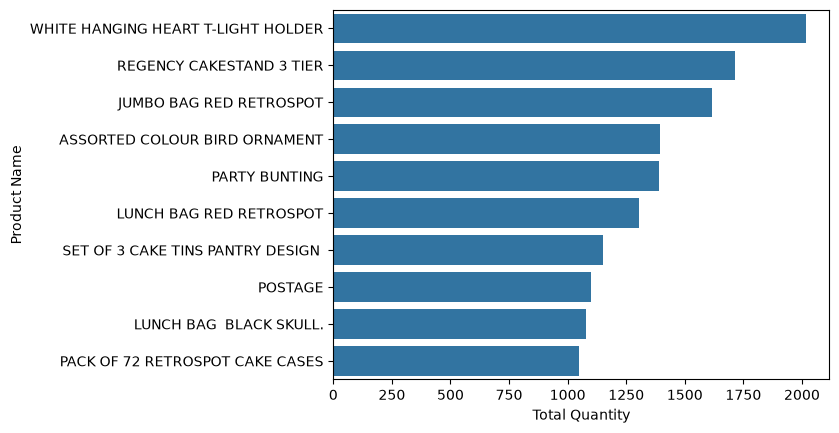

In [43]:
# Top 10 products
top_products = sns.barplot(best_products.head(10), x='Count', y='Description')
top_products.set_ylabel('Product Name')
top_products.set_xlabel('Total Quantity')
top_products

## customer by country

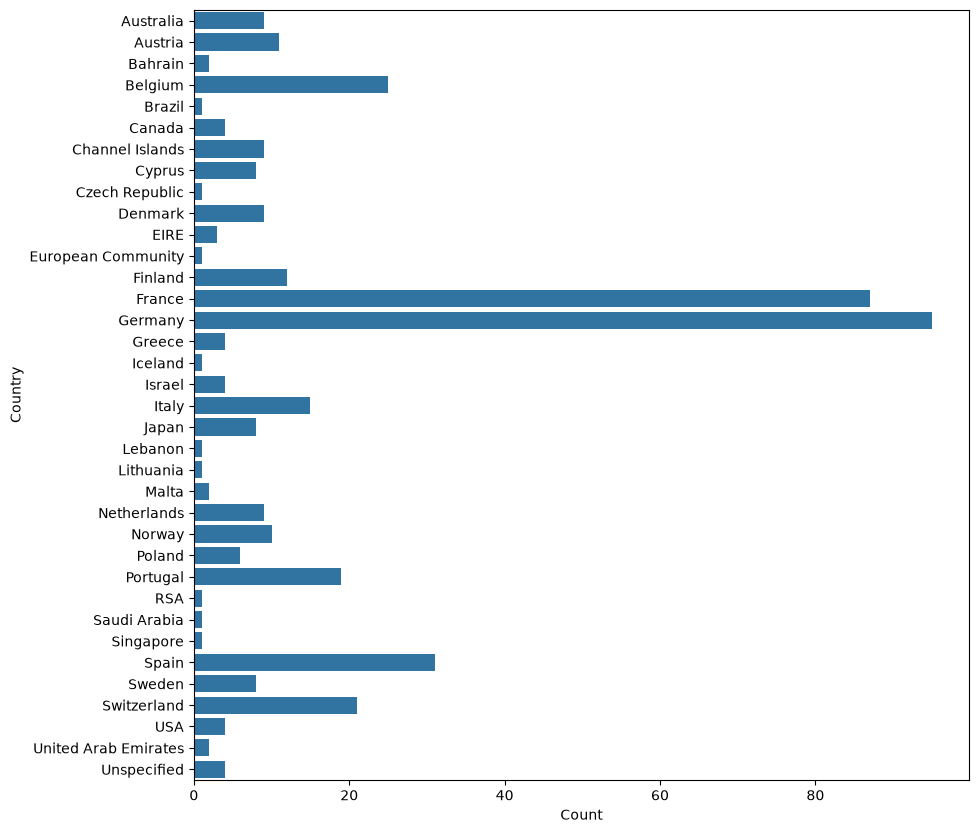

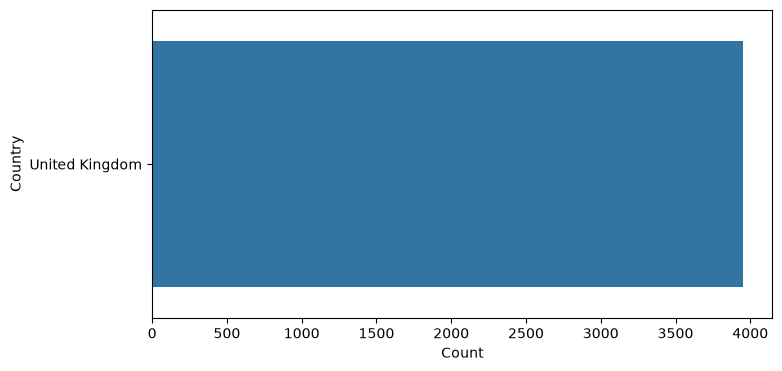

In [44]:
# customer by country
total_customers_by_country_low = total_customers_by_country[total_customers_by_country['Count'] < 100]
total_customers_by_country_high = total_customers_by_country[total_customers_by_country['Count'] > 100]
plt.figure(figsize=(10,10))
geography_low = sns.barplot(total_customers_by_country_low, x ='Count', y='Country')
plt.show()

plt.figure(figsize=(8,4))
geography_high =  sns.barplot(total_customers_by_country_high, x ='Count', y='Country')
plt.show()

## RFM

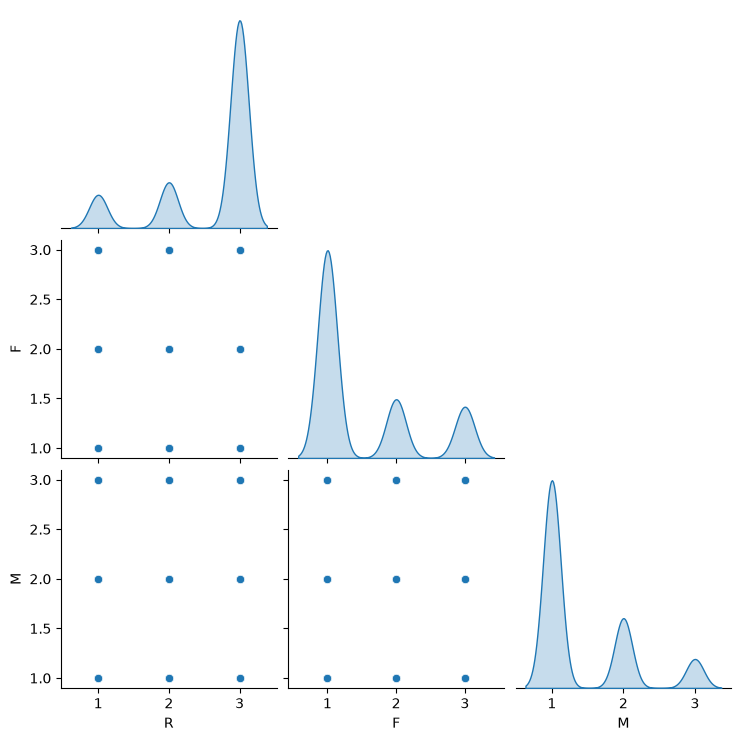

In [45]:
# RFM
sns.pairplot(clients_inf[['R', 'F', 'M']], diag_kind='kde', corner=True)

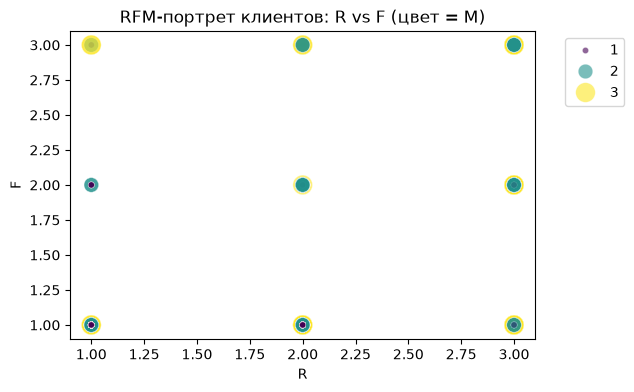

In [46]:
plt.figure(figsize=(6, 4))
scatter = sns.scatterplot(data=clients_inf, x='R', y='F', hue='M', size='M', 
                          palette='viridis', sizes=(20, 200), alpha=0.6)
plt.title('RFM-портрет клиентов: R vs F (цвет = M)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

## orders by total revenue

<Axes: xlabel='type', ylabel='Count'>

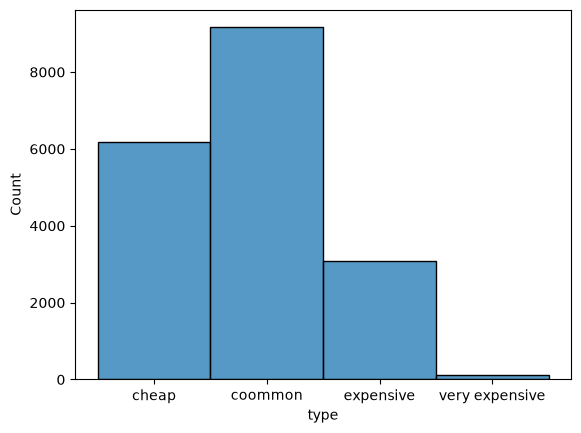

In [47]:
# orders by total revenue
sns.histplot(price_per_order_sales, x='type')

## average revenue per weekday

<Axes: xlabel='WeekDay', ylabel='AverageRevenue'>

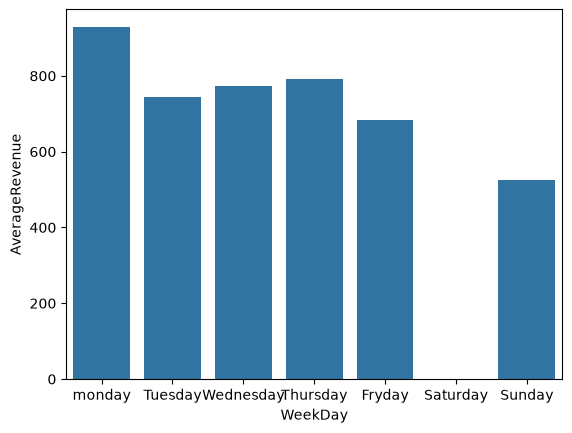

In [48]:
# average revenue per weekday
sns.barplot(avg_revenue_per_weekday, x='WeekDay', y='AverageRevenue')

## correlation matrix

<Axes: >

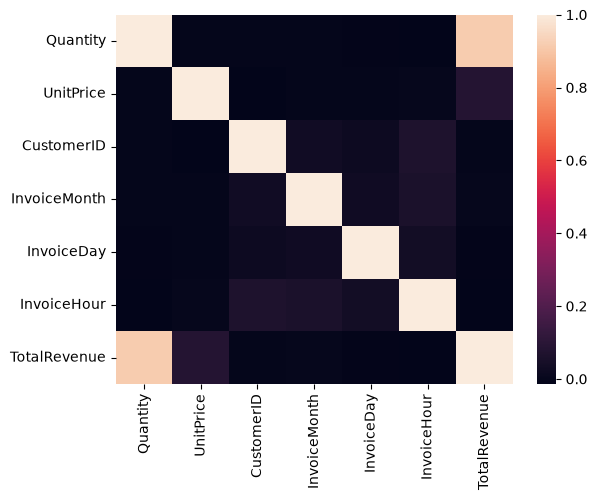

In [49]:
# correlation matrix
corr = df_sales.corr(numeric_only=True)
sns.heatmap(corr)

# Review

In [50]:
print(f'Result of common analysis \n ')
print(f'Time analysis: \n')
print(f'Best month: {pd.to_datetime(max_month, format='%m').month_name()}, max revenue: {max_revenue_per_month} \n')
print(f'Best weekday: {pd.to_datetime(max_weekday, format='%u').day_name()}, max orders: {max_orders_per_weekday} \n')
print(f'Product analysis: \n')
print(f'Top-10 Best products by quantity: \n {products_by_qty.sort_values(by='Quantity',ascending=False).head(5)} \n')
print(f'Top-10 best products by total revenue: \n {products_by_total_revenue.sort_values(by='TotalRevenue', ascending=False).head(10)} \n')
print(f'Number of unique products: {number_of_unique_products} \n')
print(f'Average price per 10 random products: \n {avg_price.sort_values(by='UnitPrice', ascending=False).head(10)} \n')
print(f'Client Analysis: \n')
print(f'Number of customers: {number_of_customers} \n')
print(f'Top-10 customers by orders: \n {clients_by_order_qty.sort_values(by='InvoiceNo',ascending=False).head(10)} \n')
print(f'Top-10 customers by purchase: \n {clients_by_purchases.sort_values(by= 'TotalRevenue', ascending=False).head(10)} \n')
print(f'Geographical analysis: \n')
print(f'Top-10 countries by revenue: \n {total_revenue_by_country.sort_values(by='TotalRevenue', ascending=False).head(10)} \n')
print(f'Top-10 countries with most customers: \n {total_customers_by_country.sort_values(by='Count', ascending=False).head(10)} \n')

Result of common analysis 
 
Time analysis: 

Best month: November, max revenue: 1126815.07 

Best weekday: Monday, max orders: 4977 

Product analysis: 

Top-10 Best products by quantity: 
      StockCode  Quantity
2812     84077     53119
1092     22197     48689
3235    85099B     44963
3069     84879     35215
3249    85123A     34185 

Top-10 best products by total revenue: 
      StockCode  TotalRevenue
1292     22423     132567.70
3249    85123A      93923.15
3235    85099B      83056.52
2599     47566      67628.43
3683      POST      66710.24
3069     84879      56331.91
1923     23084      51042.84
1366     22502      46963.10
2755     79321      45915.41
989      22086      41423.78 

Number of unique products: 3684 

Average price per 10 random products: 
      StockCode   UnitPrice
3661       DOT  744.147500
3662         M  178.406129
1673     22827  158.076923
1674     22828  156.428571
1508     22656  146.750000
1507     22655  143.421053
1669     22823  118.076923
1672 